# Model Prediction Evaluation

This notebook evaluates the accuracy of the model predictions for rental prices, both globally and per city (ville), and includes visualizations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
# Load the data with predictions
data_path = 'data_after_pred.csv'
df = pd.read_csv(data_path)

# Clean the data: convert surface to float (replace comma with dot)
df['surface (m²)'] = df['surface (m²)'].astype(str).str.replace(',', '.').astype(float)

# Ensure prix and prix_predicté are numeric
df['prix (€)'] = pd.to_numeric(df['prix (€)'], errors='coerce')
df['prix_predicté'] = pd.to_numeric(df['prix_predicté'], errors='coerce')

# Drop any rows with NaN in key columns
df = df.dropna(subset=['prix (€)', 'prix_predicté', 'ville'])

print(f"Loaded {len(df)} records")
print("Cities:", df['ville'].unique())

Loaded 1072 records
Cities: ['aix-en-provence' 'ajaccio' 'amiens' 'angers' 'annecy' 'antibes'
 'argenteuil' 'asnières-sur-seine' 'avignon' 'besançon' 'bordeaux' 'brest'
 'caen' 'cannes' 'chambery' 'clermont-ferrand' 'colmar' 'colombes'
 'creteil' 'villeurbanne' 'versailles' 'tours' 'tourcoing' 'toulouse'
 'toulon' 'strasbourg' 'saint-etienne' 'saint-denis' 'rouen' 'roubaix'
 'rennes' 'reims' 'perpignan' 'paris' 'orleans' 'nîmes' 'nice' 'nantes'
 'nanterre' 'nancy' 'mulhouse' 'montpellier' 'metz' 'marseille' 'lyon'
 'lille' 'lemans' 'le-havre' 'grenoble' 'dijon']


In [4]:
# Global evaluation metrics
y_true = df['prix (€)']
y_pred = df['prix_predicté']

mae_global = mean_absolute_error(y_true, y_pred)
rmse_global = np.sqrt(mean_squared_error(y_true, y_pred))
r2_global = r2_score(y_true, y_pred)

print("Global Model Performance:")
print(f"Mean Absolute Error (MAE): €{mae_global:.2f}")
print(f"Root Mean Squared Error (RMSE): €{rmse_global:.2f}")
print(f"R² Score: {r2_global:.4f}")

Global Model Performance:
Mean Absolute Error (MAE): €455.64
Root Mean Squared Error (RMSE): €914.95
R² Score: -0.8862


In [5]:
# Evaluation per city
city_metrics = []

for city in df['ville'].unique():
    city_df = df[df['ville'] == city]
    y_true_city = city_df['prix (€)']
    y_pred_city = city_df['prix_predicté']
    
    mae = mean_absolute_error(y_true_city, y_pred_city)
    rmse = np.sqrt(mean_squared_error(y_true_city, y_pred_city))
    r2 = r2_score(y_true_city, y_pred_city)
    
    city_metrics.append({
        'ville': city,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'count': len(city_df)
    })

city_metrics_df = pd.DataFrame(city_metrics)
print("\nPer City Performance:")
city_metrics_df


Per City Performance:


,ville,MAE,RMSE,R2,count
0,aix-en-provence,242.964415,294.042563,0.797250,41
1,ajaccio,166.742587,228.092425,0.345387,26
2,amiens,246.416455,630.897514,-7.752980,15
3,angers,174.767467,229.804552,0.515366,22
4,annecy,239.094269,292.824233,0.486057,22
5,antibes,884.317061,971.096299,0.156303,15
6,argenteuil,269.179443,413.501558,-1.571664,17
7,asnières-sur-seine,314.778098,406.641377,0.338415,22
8,avignon,111.545058,142.528928,0.197698,21
9,besançon,176.536239,221.229124,0.230016,19


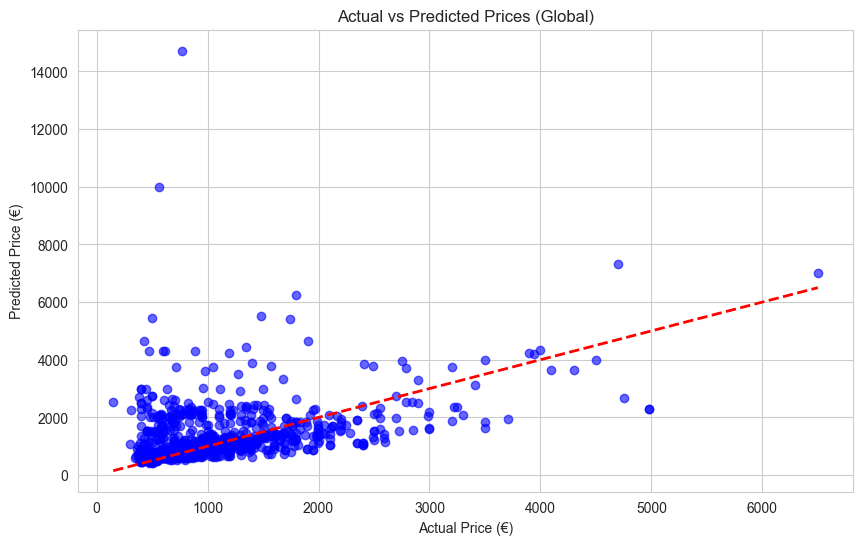

In [6]:
# Visualization 1: Global Actual vs Predicted Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.6, color='blue')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
plt.xlabel('Actual Price (€)')
plt.ylabel('Predicted Price (€)')
plt.title('Actual vs Predicted Prices (Global)')
plt.grid(True)
plt.show()

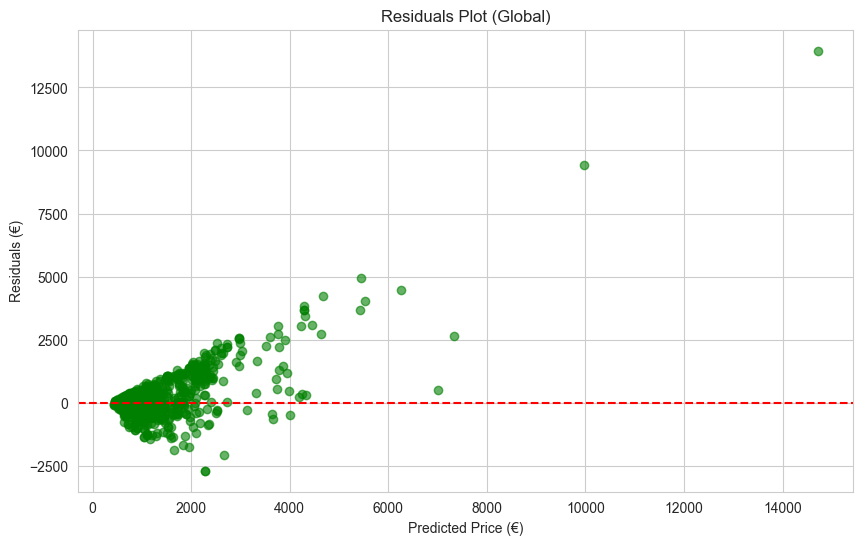

In [7]:
# Visualization 2: Residuals Plot
residuals = y_pred - y_true
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.6, color='green')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Price (€)')
plt.ylabel('Residuals (€)')
plt.title('Residuals Plot (Global)')
plt.grid(True)
plt.show()

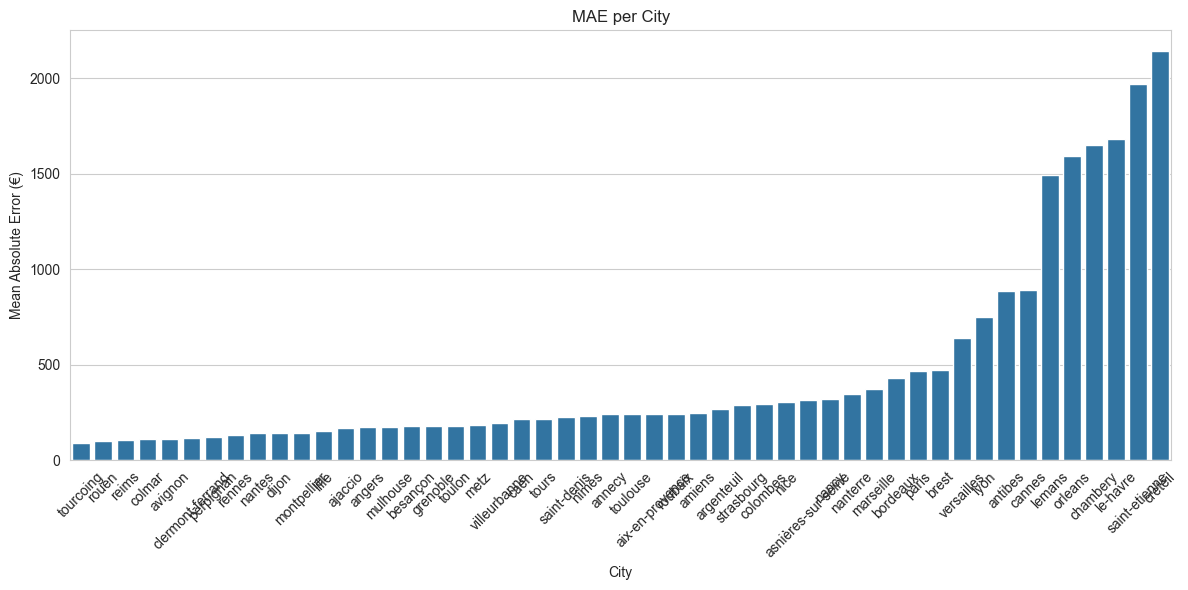

In [8]:
# Visualization 3: MAE per City
plt.figure(figsize=(12, 6))
sns.barplot(x='ville', y='MAE', data=city_metrics_df.sort_values('MAE'))
plt.xticks(rotation=45)
plt.xlabel('City')
plt.ylabel('Mean Absolute Error (€)')
plt.title('MAE per City')
plt.tight_layout()
plt.show()

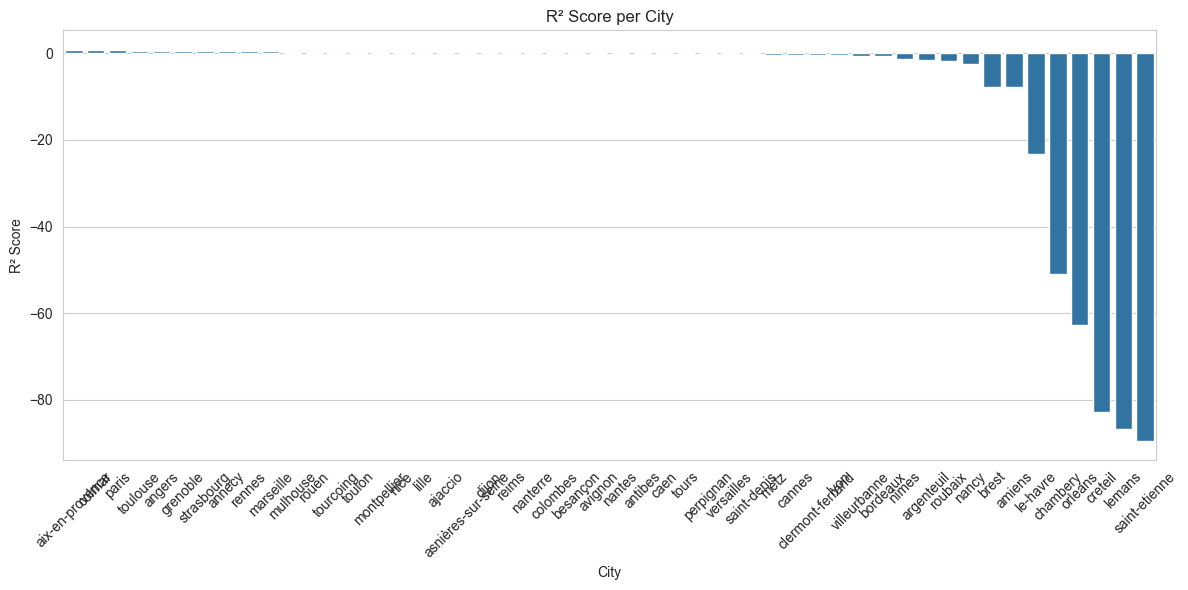

In [9]:
# Visualization 4: R² per City
plt.figure(figsize=(12, 6))
sns.barplot(x='ville', y='R2', data=city_metrics_df.sort_values('R2', ascending=False))
plt.xticks(rotation=45)
plt.xlabel('City')
plt.ylabel('R² Score')
plt.title('R² Score per City')
plt.tight_layout()
plt.show()